In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 110, 'figure.facecolor': 'white'})

# ── MOCK DATA
np.random.seed(42)
comp = pd.DataFrame({
    'company_id': range(1, 101),
    'company_name': [f"Company_{i}" for i in range(1, 101)],
    'sector': np.random.choice(['IT','Banking','FMCG','Pharma','Auto','Energy'], 100),
    'roe_percentage': np.random.uniform(5, 40, 100)
})
pl = pd.DataFrame({
    'company_id': np.repeat(range(1, 101), 10),
    'year_id': np.tile(range(2014, 2024), 100),
    'sales': np.random.uniform(500, 50000, 1000),
    'net_profit': np.random.uniform(50, 8000, 1000),
    'opm_pct': np.random.uniform(5, 35, 1000),
    'dividend_payout_pct': np.random.uniform(0, 60, 1000),
})
bs = pd.DataFrame({
    'company_id': np.repeat(range(1, 101), 10),
    'year_id': np.tile(range(2014, 2024), 100),
    'debt_to_equity': np.random.uniform(0, 3, 1000),
})
cf = pd.DataFrame({
    'company_id': np.repeat(range(1, 101), 10),
    'year_id': np.tile(range(2014, 2024), 100),
    'operating_activity': np.random.uniform(-500, 12000, 1000),
})
ana = pd.DataFrame({
    'company_id': np.repeat(range(1, 101), 3),
    'metric': np.tile(['compounded_sales_growth'], 300),
    'period_label': np.tile(['3Y', '5Y', '10Y'], 100),
    'value_pct': np.random.uniform(-5, 30, 300),
})

print("✅ Data loaded — ready for peer comparison!")

✅ Data loaded — ready for peer comparison!


In [3]:
# Step 1 — Build feature matrix
avg_opm = pl.groupby('company_id')['opm_pct'].mean().reset_index().rename(columns={'opm_pct': 'avg_opm'})
avg_dividend = pl.groupby('company_id')['dividend_payout_pct'].mean().reset_index().rename(columns={'dividend_payout_pct': 'avg_dividend'})
avg_de = bs.groupby('company_id')['debt_to_equity'].mean().reset_index().rename(columns={'debt_to_equity': 'avg_de'})

cf_pl = cf.merge(pl[['company_id', 'year_id', 'net_profit']], on=['company_id', 'year_id'], how='left')
cf_pl['ccr'] = cf_pl['operating_activity'] / cf_pl['net_profit'].replace(0, np.nan)
avg_ccr = cf_pl.groupby('company_id')['ccr'].mean().reset_index().rename(columns={'ccr': 'avg_ccr'})

cagr3 = ana[(ana['metric'] == 'compounded_sales_growth') & (ana['period_label'] == '3Y')]
cagr3 = cagr3[['company_id', 'value_pct']].rename(columns={'value_pct': 'avg_growth_3y'})

features = comp[['company_id', 'company_name', 'sector', 'roe_percentage']].copy()
features = features.merge(avg_opm, on='company_id', how='left')
features = features.merge(avg_dividend, on='company_id', how='left')
features = features.merge(avg_de, on='company_id', how='left')
features = features.merge(avg_ccr, on='company_id', how='left')
features = features.merge(cagr3, on='company_id', how='left')
features = features.fillna(features.median(numeric_only=True))

feature_cols = ['avg_opm', 'roe_percentage', 'avg_growth_3y', 'avg_de', 'avg_ccr', 'avg_dividend']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features[feature_cols])

print(f"✅ Feature matrix ready: {features.shape}")

✅ Feature matrix ready: (100, 9)


In [4]:
# Step 2 — Cosine similarity between all company pairs
sim_matrix = cosine_similarity(X_scaled)
sim_df = pd.DataFrame(sim_matrix,
                       index=features['company_name'],
                       columns=features['company_name'])

print(f"Similarity matrix shape: {sim_df.shape}")
print("\nSample — Company_1 top similarities:")
print(sim_df['Company_1'].sort_values(ascending=False).head(6))

Similarity matrix shape: (100, 100)

Sample — Company_1 top similarities:
company_name
Company_1     1.000000
Company_90    0.822858
Company_25    0.792313
Company_7     0.732980
Company_38    0.661210
Company_99    0.657160
Name: Company_1, dtype: float64


In [5]:
# Step 3 — Find top 5 peers for each company
def get_top_peers(company_name, n=5):
    if company_name not in sim_df.columns:
        return []
    scores = sim_df[company_name].drop(company_name)
    top = scores.nlargest(n)
    result = []
    for peer, score in top.items():
        sector = features[features['company_name'] == peer]['sector'].values[0]
        result.append({
            'peer_name': peer,
            'similarity': round(score, 4),
            'sector': sector
        })
    return result

# Build full peer mapping
peer_mapping = []
for company in features['company_name']:
    peers = get_top_peers(company, n=5)
    for rank, peer in enumerate(peers, 1):
        peer_mapping.append({
            'company_name': company,
            'company_sector': features[features['company_name'] == company]['sector'].values[0],
            'peer_rank': rank,
            'peer_name': peer['peer_name'],
            'peer_sector': peer['sector'],
            'similarity_score': peer['similarity']
        })

peer_df = pd.DataFrame(peer_mapping)
print(f"✅ Peer mapping done — {len(peer_df)} records")
display(peer_df[peer_df['company_name'] == 'Company_1'])

✅ Peer mapping done — 500 records


,company_name,company_sector,peer_rank,peer_name,peer_sector,similarity_score
0,Company_1,Pharma,1,Company_90,Auto,0.8229
1,Company_1,Pharma,2,Company_25,Energy,0.7923
2,Company_1,Pharma,3,Company_7,FMCG,0.7330
3,Company_1,Pharma,4,Company_38,FMCG,0.6612
4,Company_1,Pharma,5,Company_99,IT,0.6572


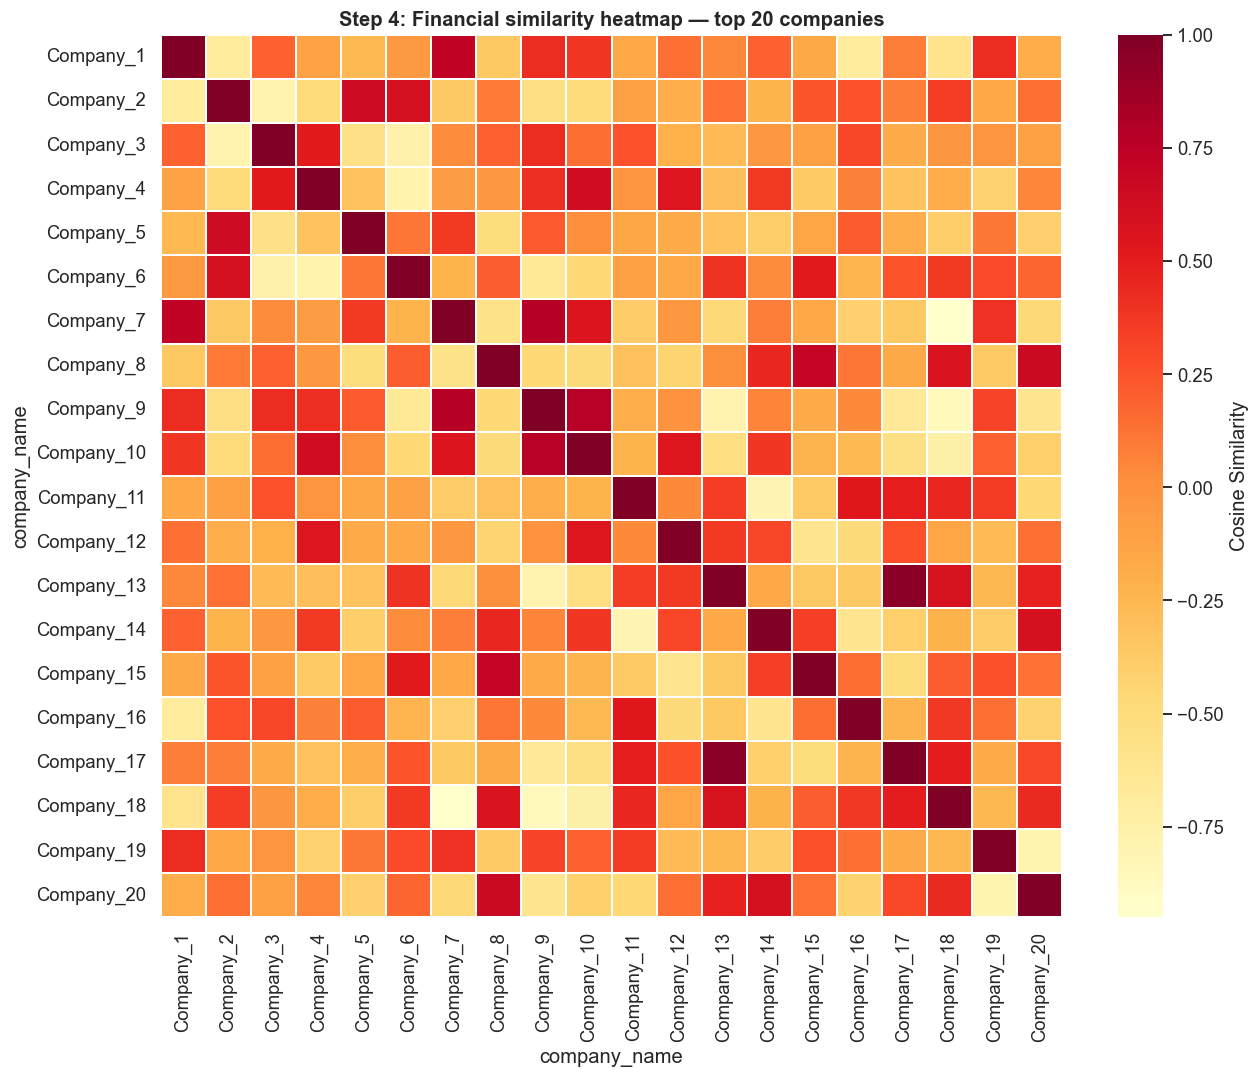

In [6]:
# Step 4 — Similarity heatmap (top 20 companies)
top20 = features['company_name'].head(20).tolist()
sim_top20 = sim_df.loc[top20, top20]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(sim_top20, cmap='YlOrRd', annot=False,
            linewidths=0.3, ax=ax,
            cbar_kws={'label': 'Cosine Similarity'})
ax.set_title('Step 4: Financial similarity heatmap — top 20 companies', fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# Step 5 — Export peer mapping
os.makedirs('../data', exist_ok=True)
peer_df.to_csv('../data/peer_mapping.csv', index=False)
print("✅ Exported to data/peer_mapping.csv")

print("\n" + "="*60)
print("NOTEBOOK 5 SUMMARY — Peer Comparison Engine")
print("="*60)
print(f"Companies mapped : {features.shape[0]}")
print(f"Peers per company: 5")
print(f"Total records    : {len(peer_df)}")
print(f"\nSample peers for Company_1:")
display(peer_df[peer_df['company_name'] == 'Company_1'][
    ['peer_rank', 'peer_name', 'peer_sector', 'similarity_score']
])
print("\n✅ Ready for Notebook 6 — Trend Analysis & Forecasting!")

✅ Exported to data/peer_mapping.csv

NOTEBOOK 5 SUMMARY — Peer Comparison Engine
Companies mapped : 100
Peers per company: 5
Total records    : 500

Sample peers for Company_1:


,peer_rank,peer_name,peer_sector,similarity_score
0,1,Company_90,Auto,0.8229
1,2,Company_25,Energy,0.7923
2,3,Company_7,FMCG,0.7330
3,4,Company_38,FMCG,0.6612
4,5,Company_99,IT,0.6572



✅ Ready for Notebook 6 — Trend Analysis & Forecasting!
